In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import os

# List of the 8 representative benchmark files
file_list = [
    'mmlu_external.csv', 'gsm8k_external.csv', 'hella_swag_external.csv',
    'gpqa_diamond.csv', 'frontiermath.csv', 'arc_agi_external.csv',
    'swe_bench_verified.csv', 'chess_puzzles.csv'
]
folder_path = 'benchmark_data'
all_data = []

for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    try:
        temp_df = pd.read_csv(file_path)
        
        # Standardizing column names across different Epoch AI datasets
        column_mapping = {
            'Model version': 'model_name',
            'Release date': 'release_date',
            'Organization': 'maker',        
            'EM': 'score',
            'mean_score': 'score',
            'Score': 'score',
            'Overall accuracy': 'score'
        }
        temp_df = temp_df.rename(columns=column_mapping)
        
        # Extracting benchmark name from filename
        bench_name = file_name.replace('.csv', '').replace('_external', '').replace('_verified', '').upper()
        temp_df['benchmark_name'] = bench_name
        
        # Handling missing organization info
        if 'maker' not in temp_df.columns:
            temp_df['maker'] = 'Unknown'
            
        if 'model_name' in temp_df.columns and 'score' in temp_df.columns and 'release_date' in temp_df.columns:
            temp_df = temp_df[['model_name', 'release_date', 'score', 'benchmark_name', 'maker']]
            all_data.append(temp_df)
            
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

if all_data:
    df = pd.concat(all_data, ignore_index=True)
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['score'] = pd.to_numeric(df['score'], errors='coerce')
    
    # Normalizing scores to 0-100 range
    if df['score'].max() <= 1.0:
        df['score'] = df['score'] * 100
        
    df = df.dropna(subset=['release_date', 'score'])
    print(f"Successfully loaded and merged {len(all_data)} benchmark datasets.")

Successfully loaded and merged 8 benchmark datasets.


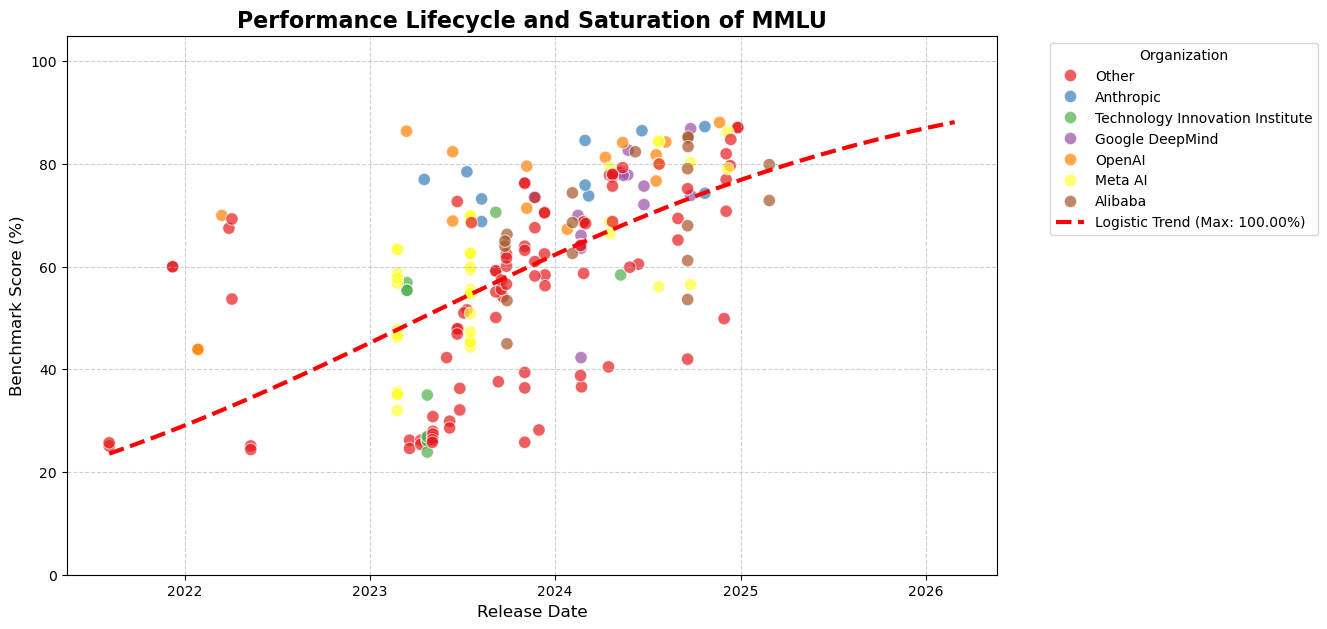

The theoretical ceiling of MMLU is: 100.0000%


In [6]:
def logistic_func(x, L, k, x0):
    """Standard logistic growth function for S-curve fitting."""
    return L / (1 + np.exp(-k * (x - x0)))

def plot_lifecycle_curve(df, target_benchmark):
    """
    Plots the performance lifecycle of a specific benchmark using an S-curve.
    Returns the fitted parameters (popt) for further analysis.
    """
    b_df = df[df['benchmark_name'] == target_benchmark].copy()
    
    if b_df.empty:
        print(f"No data found for {target_benchmark}")
        return None

    # Calculating time delta in months for curve fitting
    # Using 30.44 days as the average month duration
    b_df['months_since_start'] = (b_df['release_date'] - b_df['release_date'].min()).dt.days / 30.44
    x_data = b_df['months_since_start'].values
    y_data = b_df['score'].values

    # Fitting the S-curve
    # Constraint: Max score (L) is capped at 100%
    try:
        popt, _ = curve_fit(
            logistic_func, 
            x_data, 
            y_data, 
            p0=[100, 0.1, np.median(x_data)], 
            bounds=([0, 0, -100], [100, 1, 1000])
        )
    except RuntimeError:
        # Fallback if optimization fails
        popt = [100, 0.1, np.median(x_data)]

    # Grouping organizations to keep the legend clean (Top 6 + Other)
    top_makers = b_df['maker'].value_counts().nlargest(6).index
    b_df['maker_grouped'] = b_df['maker'].apply(lambda x: x if x in top_makers else 'Other')

    # Figure settings
    plt.figure(figsize=(12, 7))
    
    # Scatter plot of actual model performances
    sns.scatterplot(
        data=b_df, 
        x='release_date', 
        y='score', 
        hue='maker_grouped', 
        palette='Set1', 
        s=80, 
        alpha=0.7
    )
    
    # Generating the smooth trendline
    x_smooth = np.linspace(x_data.min(), x_data.max() + 12, 100)
    y_smooth = logistic_func(x_smooth, *popt)
    date_smooth = b_df['release_date'].min() + pd.to_timedelta(x_smooth * 30.44, unit='D')
    
    # Plotting the logistic trendline
    plt.plot(
        date_smooth, 
        y_smooth, 
        color='red', 
        linestyle='--', 
        linewidth=3, 
        label=f'Logistic Trend (Max: {popt[0]:.2f}%)'
    )
    
    # Chart styling
    plt.title(f'Performance Lifecycle and Saturation of {target_benchmark}', fontsize=16, fontweight='bold')
    plt.xlabel('Release Date', fontsize=12)
    plt.ylabel('Benchmark Score (%)', fontsize=12)
    plt.ylim(0, 105) # Visual buffer above the 100% line
    
    # Legend and grid layout
    plt.legend(title='Organization', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Save the resulting figure
    plt.savefig(f'{target_benchmark}_lifecycle.png', dpi=300, bbox_inches='tight')
    plt.show()

    return popt

# --- Execution ---
# Capture the result of the function into a variable
popt_result = plot_lifecycle_curve(df, 'MMLU')

# Check if fitting was successful and print the theoretical ceiling
if popt_result is not None:
    print(f"The theoretical ceiling of MMLU is: {popt_result[0]:.4f}%")

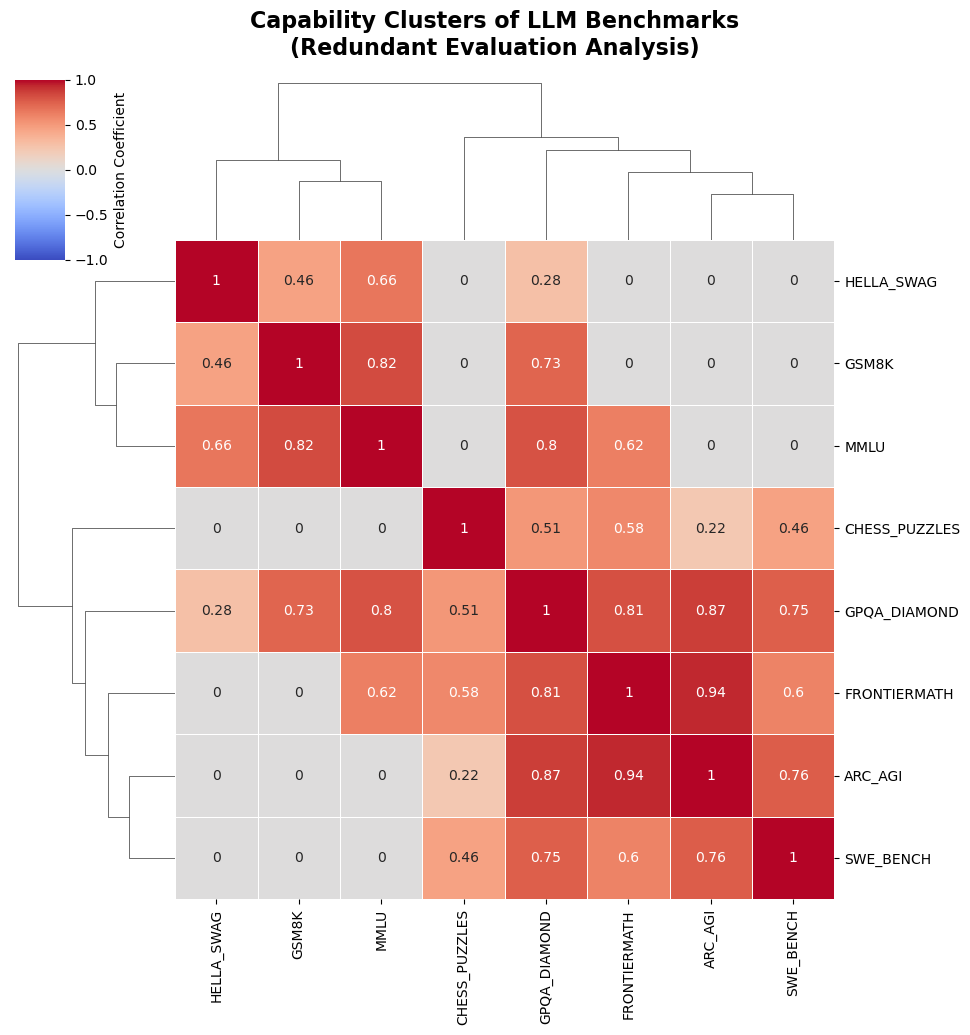

In [7]:

# ==========================================
# 1. Structural Analysis: Model-by-Benchmark Matrix
# ==========================================
# Create a pivot table: Rows = Models, Columns = Benchmarks
pivot_df = df.pivot_table(index='model_name', columns='benchmark_name', values='score')

# Calculate the Pearson correlation matrix between benchmarks
corr_matrix = pivot_df.corr().fillna(0)

# ==========================================
# 2. Plot the Clustered Heatmap
# ==========================================
# Use seaborn's clustermap to automatically perform hierarchical clustering
g = sns.clustermap(
    corr_matrix, 
    annot=True,              # Show correlation numbers in the boxes
    cmap='coolwarm',         # Blue for negative, Red for positive correlation
    vmin=-1, vmax=1,         # Correlation ranges from -1 to 1
    linewidths=0.5,
    figsize=(10, 10),        # Make the figure slightly larger for 8 benchmarks
    cbar_kws={'label': 'Correlation Coefficient'}
)

# Set the title
g.fig.suptitle('Capability Clusters of LLM Benchmarks\n(Redundant Evaluation Analysis)', y=1.05, fontsize=16, fontweight='bold')

# Remove the ugly default x and y axis labels
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')

# Save and show the plot
plt.savefig('clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
import glob

folder_path = 'benchmark_data'
file_paths = glob.glob(os.path.join(folder_path, '*.csv'))

summary_data = []

print(f"Scanning {len(file_paths)} files...")

for file in file_paths:
    # Skip any metadata files that aren't benchmarks
    if 'models' in file.lower(): continue 
        
    try:
        df = pd.read_csv(file)
        benchmark_name = os.path.basename(file).replace('.csv', '')
        
        # Ensure it has the columns we expect (from your chess_puzzles example)
        if 'mean_score' not in df.columns or 'Release date' not in df.columns:
            continue
            
        # Clean dates and drop bad rows
        df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
        df = df.dropna(subset=['Release date', 'mean_score'])
        
        if df.empty: continue
        
        # Look at the most recent year of data to check current saturation
        latest_date = df['Release date'].max()
        recent_models = df[df['Release date'].dt.year == latest_date.year]
        
        if len(recent_models) < 2:
            continue # Skip if not enough data to compare
            
        # Calculate Lifecycle Metrics
        max_score = recent_models['mean_score'].max()
        median_score = recent_models['mean_score'].median()
        gap = max_score - median_score
        
        summary_data.append({
            'Benchmark': benchmark_name,
            'Max Score': round(max_score, 3),
            'Median Score': round(median_score, 3),
            'Saturation Gap': round(gap, 3),
            'Total Models': len(df)
        })
    except Exception as e:
        pass # Skip files that cause errors to keep it moving

# 3. Print the Results
if summary_data:
    df_summary = pd.DataFrame(summary_data)

    print("\n--- MOST SATURATED BENCHMARKS ")
    # Sort by smallest gap and highest max score
    print(df_summary.sort_values(['Saturation Gap', 'Max Score'], ascending=[True, False]).head(3).to_string(index=False))

    print("\n--- MOST FRONTIER BENCHMARKS ")
    print(df_summary.sort_values('Max Score', ascending=True).head(3).to_string(index=False))
else:
    print("No valid benchmark data found. Double check the folder name.")

Scanning 10 files...

--- MOST SATURATED BENCHMARKS 
               Benchmark  Max Score  Median Score  Saturation Gap  Total Models
otis_mock_aime_2024_2025      0.956         0.926           0.030           126
            frontiermath      0.407         0.376           0.031            83
      swe_bench_verified      0.787         0.752           0.035            24

--- MOST FRONTIER BENCHMARKS 
          Benchmark  Max Score  Median Score  Saturation Gap  Total Models
frontiermath_tier_4      0.229         0.156           0.073            53
       frontiermath      0.407         0.376           0.031            83
      chess_puzzles      0.550         0.130           0.420            27


Plot saved successfully as: Focused_Benchmark_Analysis.png


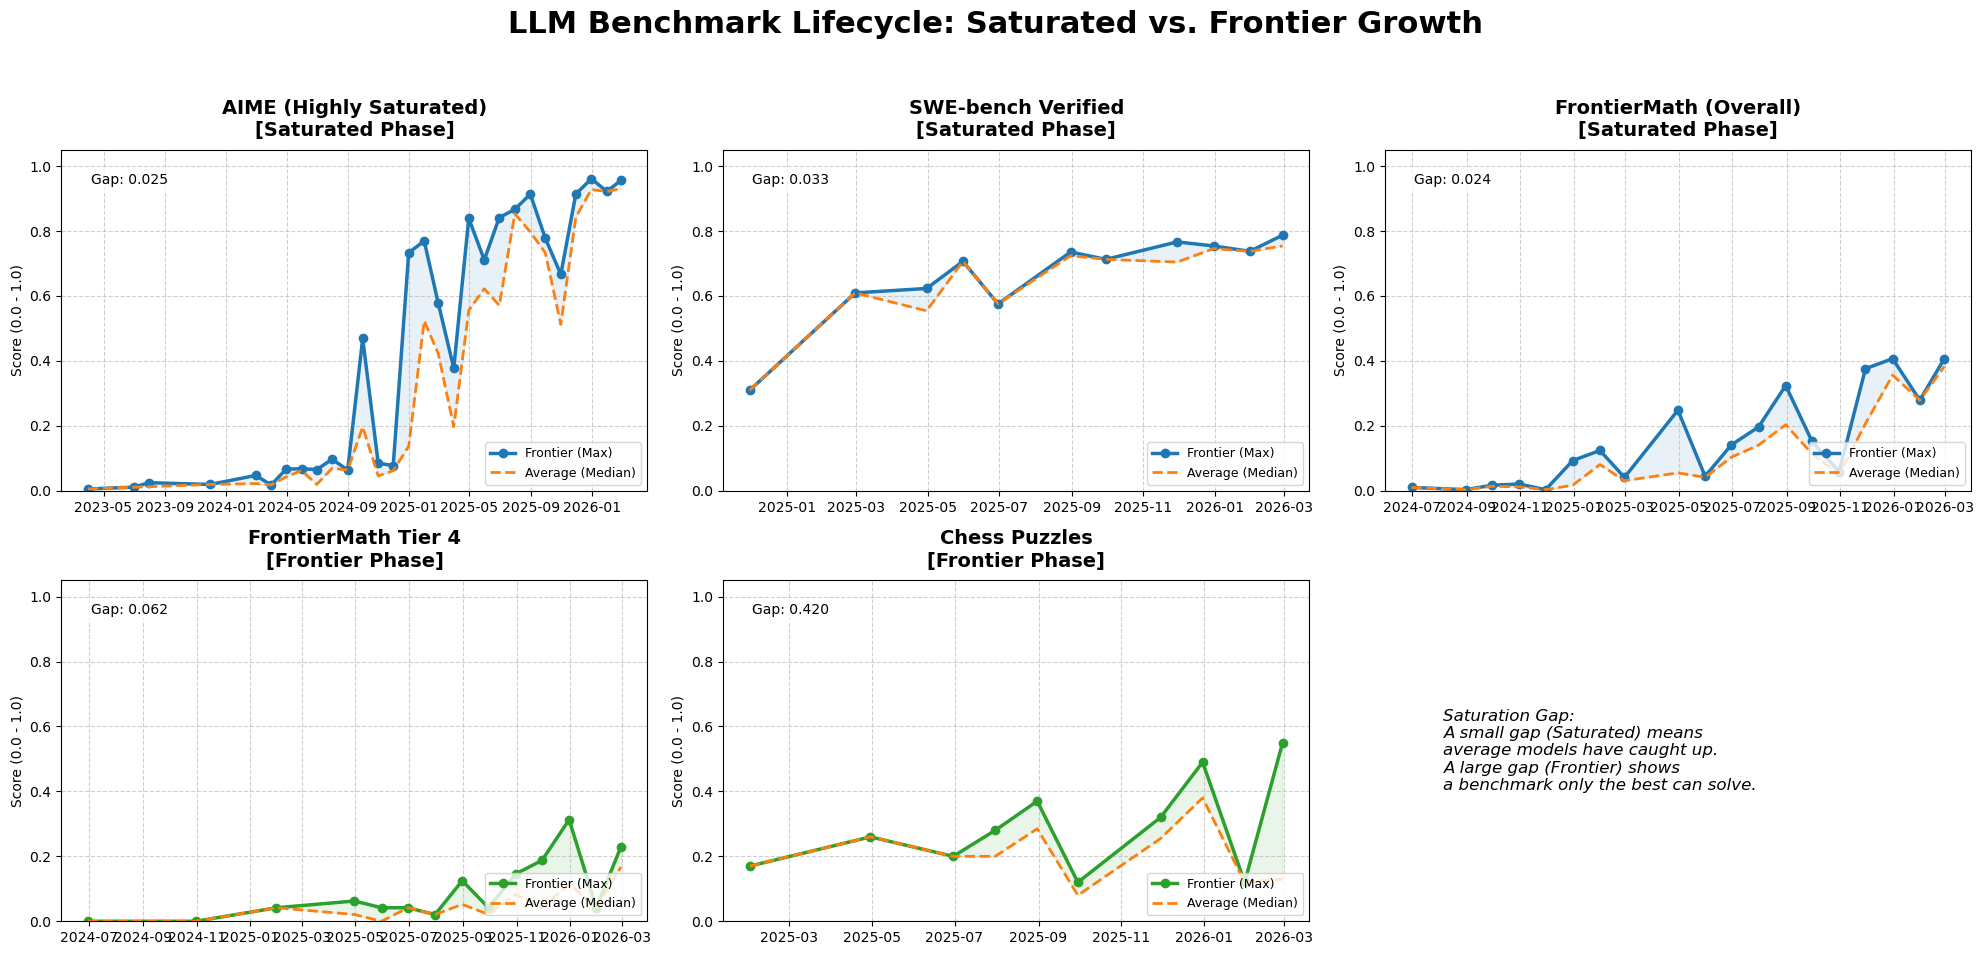

In [9]:
# Configuration
DATA_DIR = 'benchmark_data'
OUTPUT_FILE = 'Focused_Benchmark_Analysis.png'

# Specific files identified in your scan
benchmarks = [
    # Most Saturated (Legacy/Phase 1)
    ('otis_mock_aime_2024_2025.csv', 'AIME (Highly Saturated)', 'Saturated'),
    ('swe_bench_verified.csv', 'SWE-bench Verified', 'Saturated'),
    ('frontiermath.csv', 'FrontierMath (Overall)', 'Saturated'),
    # Most Frontier (Phase 2/3)
    ('frontiermath_tier_4.csv', 'FrontierMath Tier 4', 'Frontier'),
    ('chess_puzzles.csv', 'Chess Puzzles', 'Frontier')
]

def get_trend_data(file_name):
    """Processes benchmark CSV and returns monthly aggregated stats."""
    file_path = os.path.join(DATA_DIR, file_name)
    if not os.path.exists(file_path):
        print(f"Warning: {file_name} not found.")
        return None
    
    try:
        df = pd.read_csv(file_path)
        df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
        df = df.dropna(subset=['Release date', 'mean_score'])
        df = df.sort_values('Release date')
        
        if df.empty:
            return None
            
        # Group by month to get frontier (max) and average (median) lines
        stats = df.groupby(pd.Grouper(key='Release date', freq='ME'))['mean_score'].agg(['max', 'median']).dropna()
        return stats
    except Exception as e:
        print(f"Error processing {file_name}: {e}")
        return None

def create_focused_plot():
    # Setup a 2x3 grid (can accommodate up to 6 plots)
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    axes = axes.flatten()
    fig.suptitle('LLM Benchmark Lifecycle: Saturated vs. Frontier Growth', fontsize=22, fontweight='bold', y=0.98)

    for i, (file_name, display_name, category) in enumerate(benchmarks):
        stats = get_trend_data(file_name)
        ax = axes[i]
        
        if stats is not None:
            # Pick color scheme based on category
            line_color = '#1f77b4' if category == 'Saturated' else '#2ca02c' # Blue for sat, Green for frontier
            
            # Plot Max and Median
            ax.plot(stats.index, stats['max'], label='Frontier (Max)', color=line_color, marker='o', linewidth=2.5)
            ax.plot(stats.index, stats['median'], label='Average (Median)', color='#ff7f0e', linestyle='--', linewidth=2)
            
            # Highlight the gap (Saturation area)
            ax.fill_between(stats.index, stats['median'], stats['max'], color=line_color, alpha=0.1)
            
            # Formatting
            ax.set_title(f"{display_name}\n[{category} Phase]", fontsize=14, fontweight='bold', pad=10)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel('Score (0.0 - 1.0)')
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend(loc='lower right', fontsize=9)
            
            # Add saturation info label
            latest_gap = stats['max'].iloc[-1] - stats['median'].iloc[-1]
            ax.text(0.05, 0.9, f"Gap: {latest_gap:.3f}", transform=ax.transAxes, 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # Hide the 6th (empty) subplot
    axes[5].axis('off')
    
    # Add a legend/note in the empty spot
    axes[5].text(0.1, 0.5, "Saturation Gap:\nA small gap (Saturated) means\naverage models have caught up.\nA large gap (Frontier) shows\na benchmark only the best can solve.", 
                 fontsize=12, style='italic', verticalalignment='center')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully as: {OUTPUT_FILE}")

if __name__ == "__main__":
    create_focused_plot()